# Linear Algebra Project — Latent Semantic Indexing

**Team members**

| Name | Student ID |
| --- | --- |
| Sara Ahmadi | 403400002 |
| Mahdie Yeganeh | 402400002 |
| MohammadReza Hasani | 403521222 |
| Ehsan Rezaei | 403521348 |

# Part 1 — Theory

## Question 1

# Q1 — TF and IDF, and why we need both together

## Term Frequency (TF)

TF measures how many times a word appears in one document, compared to the length of that document:

$$
\text{TF}(t, d) = \frac{\text{number of times term } t \text{ appears in document } d}{\text{total number of terms in } d}
$$

The idea is simple: if a word repeats many times in a document, it is probably an important word for that document.

## Inverse Document Frequency (IDF)

IDF looks at the whole corpus, not just one document. It asks: how rare is this word across all documents?

$$
\text{IDF}(t) = \log\left(\frac{N}{\text{df}(t)}\right)
$$

Here $N$ is the total number of documents, and $\text{df}(t)$ is the number of documents that contain the word $t$ at least once. Common words like "the," "is," "said" appear in almost every document, so their IDF is close to zero — they do not help us tell documents apart. A word that appears in only a few documents gets a high IDF, because it is a strong signal about what that document is really about.

## TF-IDF: putting the two together

TF-IDF is the product of TF and IDF:

$$
\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)
$$

A word gets a high TF-IDF score only when both things are true: it appears often in the document (high TF), **and** it is rare in the rest of the corpus (high IDF). If either one is missing, the score goes down.

### Example

Say we have a corpus with $N = 4$ documents. We look at document $d_1$, which has 100 words.

**Word "the"**: it appears 8 times in $d_1$. It also appears in all 4 documents.

$$
\text{TF}(\text{the}, d_1) = \frac{8}{100} = 0.08
$$

$$
\text{IDF}(\text{the}) = \log\left(\frac{4}{4}\right) = \log(1) = 0
$$

$$
\text{TF-IDF}(\text{the}, d_1) = 0.08 \times 0 = 0
$$

**Word "election"**: it appears only 3 times in $d_1$. But in the whole corpus, it appears in only 2 out of 4 documents.

$$
\text{TF}(\text{election}, d_1) = \frac{3}{100} = 0.03
$$

$$
\text{IDF}(\text{election}) = \log\left(\frac{4}{2}\right) = \log(2) \approx 0.301
$$

$$
\text{TF-IDF}(\text{election}, d_1) = 0.03 \times 0.301 \approx 0.009
$$

Even though "the" appears more times than "election" (8 vs. 3), its TF-IDF score is exactly $0$, while "election" gets a positive score. If we only used TF, "the" would look more important. TF-IDF fixes this, because "the" does not help us tell documents apart.

## Why we cannot use TF or IDF alone — we need both

TF and IDF answer two different questions. Each one has a weak point, and the other one fixes it.

If we use only TF, the words with the highest score will be stopwords like "the," "and," "a." This happens because these words repeat a lot in every document, not because they are important. A high TF score does not mean the word has real meaning — it may just be a common word in the language.

If we use only IDF, we get the opposite problem. A rare word gets a high score just because it is rare, even if it barely appears in the document we are looking at. It does not matter if the word is a typo, a name that appears once by chance, or just noise. IDF alone cannot tell us if the word actually matters for one specific document.

![TF-IDF as two lenses that must be combined](images-2.jpeg)

The picture shows this idea well. TF and IDF are like two lenses of one pair of glasses. If we look through only one lens — only TF or only IDF — nothing becomes clear. Words like "he," "she," "it," "the," "they" stay blurry in the background, no matter which single lens we use. This happens because TF alone cannot tell which words are stopwords, and IDF alone cannot tell which words matter for a specific document. Only when we use both lenses together do the real, meaningful words — "relevance," "consumer," "forest," "travel" — come into focus, while the common background words stay blurry.

This is why we always multiply TF and IDF together, instead of using them one at a time. TF alone rewards words just for repeating. IDF alone rewards words just for being rare. Only together do they fix each other's weak points and give us a score that really shows which words matter.


## Question 2

# Q2 — The Elbow Point method for choosing the rank in Truncated SVD

## What we want to do

When we compute the SVD of a matrix $A_{d\times n} = U\Sigma V^T$, the diagonal of $\Sigma$ holds the singular values $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r \ge 0$, sorted from largest to smallest. Each singular value tells us how much structure of the matrix is kept in its matching pair of vectors. The first singular value is the strongest and most important pattern in the data. The last ones are the weakest and least important.

Truncated SVD keeps only the first $k$ singular values (and their matching vectors), and drops the rest. This gives us a rank-$k$ approximation:

$$
A_k = U_k \Sigma_k V_k^T
$$

So the real question is simple: **how do we choose $k$?** We want a $k$ that is small — so the approximation is cheap and easy to store — but still keeps almost all the useful information in $A$. The elbow point method is one simple way to choose this $k$.

## Why we need a method to choose $k$

If $k$ is too small, we lose real structure, and the approximation becomes a poor summary of the original matrix. If $k$ is too large, we keep singular values that add almost nothing useful — we just carry extra noise for no real benefit. We want to find the point between these two: keep everything important, and drop everything that is not.

## The idea behind the elbow point

If we plot the singular values on the y-axis, against their rank index $i = 1, 2, 3, \dots$ on the x-axis, the curve almost always looks the same for real data: it drops fast for the first few values, then the drop becomes slower, and the curve becomes almost flat for a long tail.

That bend — where the curve stops dropping fast and starts to flatten — is called the "elbow" (or the "knee"). It looks like the inside of a bent arm, which is where the name comes from.

The idea is simple: the singular values *before* the elbow are large and clearly different from each other. They show real, important structure in the data — this is the "signal." The singular values *after* the elbow are small, close to each other, and drop slowly. This is the sign of noise, or small details that do not matter much. So we choose $k$ to be the index at the elbow: we keep everything that looks like signal, and drop everything that looks like noise.

We see the same idea in other places too, like choosing the number of clusters $k$ in k-means clustering. There, instead of singular values, we plot how much variance is explained as we add more clusters. The shape of the curve is a little different, but the logic for choosing the bend point is the same:

![Elbow method example: percent of variance explained vs. number of clusters, with the elbow at k = 4](elbow_method.jpg)

*Source: [Elbow method (clustering) — Wikipedia](https://en.wikipedia.org/wiki/Elbow_method_(clustering))*

In this picture, going from 2 to 3 to 4 clusters explains a lot more variance each time. But after $k = 4$ (circled in red), each extra cluster adds almost nothing. That circled point is the elbow — after it, we pay for more complexity but get almost nothing back. Choosing $k$ for singular values works the same way: look for the point where the curve stops dropping fast and becomes flat.

## Why this is a good tradeoff

Cutting at the elbow gives us a rank $k$ that is usually much smaller than the true rank $r$ of the matrix, but it still keeps most of the matrix's information. This works because the singular values we drop are small, and (as we will see in Q3) the reconstruction error depends directly on the size of the singular values we drop. So the elbow point is close to the point where adding more dimensions stops being worth it: past this point, we use more dimensions but gain very little extra information.

In practice, we do this visually: plot the singular values, look for where the curve bends, and pick that index as $k$. This is a heuristic, not an exact rule — the bend is not always sharp. But it is fast, simple, and it works well when singular values drop quickly, which is common for text data, like the term-document matrices used in LSI.


## Question 3

# Q3 — Computing the reconstruction error of Truncated SVD

## What we want to do

Once we cut the SVD down to rank $k$, we want to know how much information we actually lost. The reconstruction error measures this — it is the gap between the original matrix $A$ and the approximation $A_k$ we built from it. This tells us if our choice of $k$ (for example, from the elbow method in Q2) was good enough.

## Setup

Let $A_{d\times n}$ be the original matrix, with full SVD:

$$
A = U \Sigma V^T, \qquad \Sigma = \text{diag}(\sigma_1, \sigma_2, \dots, \sigma_r), \quad \sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r \ge 0
$$

Here $r$ is the rank of $A$. The rank-$k$ truncated approximation is:

$$
A_k = U_k \Sigma_k V_k^T
$$

built from only the top $k$ singular values and their matching vectors.

![Visualisation of the singular value decomposition M = U Σ V*, showing the shape of each matrix](svd_reconstruction.svg)

*Source: [Singular value decomposition — Wikipedia](https://en.wikipedia.org/wiki/Singular_value_decomposition), diagram by CMG Lee*

The picture shows the full decomposition of a matrix $M$ into $U$, $\Sigma$, and $V^*$. Truncated SVD keeps only the first $k$ columns of $U$, the first $k$ singular values in $\Sigma$, and the first $k$ rows of $V^*$ — the rest gets cut off. The reconstruction error tells us how much we lose by cutting there.

## The error itself

A natural way to measure "how different are these two matrices" is the Frobenius norm of their difference:

$$
\|A - A_k\|_F = \sqrt{\sum_{i,j} \left(A_{ij} - (A_k)_{ij}\right)^2}
$$

We do not actually need to subtract the two matrices entry by entry to get this number. Because of how SVD is built, it turns out that:

$$
\|A - A_k\|_F = \sqrt{\sum_{i=k+1}^{r} \sigma_i^2}
$$

In words: the reconstruction error is just the size of the singular values we threw away. This comes from the Eckart–Young theorem, which also tells us something useful — $A_k$ is not just *a* rank-$k$ approximation, it is the *best possible* rank-$k$ approximation of $A$, using this norm. No other rank-$k$ matrix can get closer to $A$ than the truncated SVD does.

This is also why the elbow-point idea from Q2 works: the singular values we cut after the elbow are small, so $\sum_{i=k+1}^{r}\sigma_i^2$ stays small. This means the reconstruction error stays small too, even though we threw away most of the dimensions.

## Relative error

In practice, it is often more useful to report a *relative* reconstruction error, instead of the raw Frobenius norm, because the raw number depends on the scale of the data:

$$
\text{relative error} = \frac{\|A - A_k\|_F}{\|A\|_F} = \sqrt{\frac{\sum_{i=k+1}^{r}\sigma_i^2}{\sum_{i=1}^{r}\sigma_i^2}}
$$

This gives us a number between 0 and 1 (0% to 100%), and we can use it directly to choose $k$. For example: "keep enough singular values so the relative reconstruction error stays under 5%."


## Question 4

# Q4 Euclidean Distance vs. Cosine Similarity

After we turn documents or words into numeric vectors (bag-of-words, TF-IDF, or the latent-space vectors from LSI), we need a way to measure how similar two vectors are. Euclidean distance and cosine similarity are the two most common ways to do this, and they measure different things.

## Euclidean Distance

For two vectors $x, y \in \mathbb{R}^n$:

$$
d(x, y) = \|x - y\|_2 = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$

This is the normal straight-line distance, the same one used in 2D or 3D geometry, just extended to $n$ dimensions.

- **Minimum:** $d(x,y) = 0$, when $x = y$. The two vectors are exactly the same.
- **Maximum:** no upper limit. The farther apart the two points are, the larger this value gets, and it can grow forever.

So a small distance means the vectors are almost the same, and a large distance means they are very different. There is no fixed scale, so a distance only makes sense when compared to other distances in the same dataset.

## Cosine Similarity

For the same $x$ and $y$:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\| \, \|y\|} = \frac{\sum_{i=1}^{n} x_i y_i}{\sqrt{\sum_i x_i^2}\sqrt{\sum_i y_i^2}}
$$

This is the cosine of the angle $\theta$ between the two vectors. Instead of measuring distance, it measures direction, and it does not care about the length (magnitude) of the vectors at all.

- **Maximum:** $\cos(\theta) = 1$ at $\theta = 0°$. The two vectors point in exactly the same direction.
- **Minimum:** $\cos(\theta) = -1$ at $\theta = 180°$. The vectors point in exactly opposite directions. But since word counts and TF-IDF values are never negative, in our case the value can only be between 0 and 1. A value of 0 means the two vectors are orthogonal, meaning the two texts share no common weighted words.

## Why the difference matters

The main difference is that cosine similarity ignores scale, but Euclidean distance does not. Imagine two documents about the same topic, using the same words in the same proportions, but one is a short paragraph and the other is a long article that repeats the same words many more times. Their vectors point in almost the same direction, so cosine similarity correctly shows they are very similar (close to 1). But because the long document's vector is much larger in magnitude, the Euclidean distance between them can be large, which wrongly suggests they are different.

This is why cosine similarity is usually used for comparing text or embedding vectors, since document length can vary a lot, but what matters is the topic direction, not the size. Euclidean distance works better when the actual size or position of the vectors carries meaning, for example when comparing physical measurements or coordinates.

## Question 5

# Q5  Standardizing numeric vectors, and why it matters before decomposing a data matrix

## What standardization is

Standardization (also called z-score normalization) rescales each feature (each column of the data matrix) so that it has mean 0 and standard deviation 1. For a feature $j$ with values $x_{1j}, x_{2j}, \dots, x_{dj}$ across all $d$ samples, with mean $\mu_j$ and standard deviation $\sigma_j$:

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}, \qquad
\mu_j = \frac{1}{d}\sum_{i=1}^{d} x_{ij}, \qquad
\sigma_j = \sqrt{\frac{1}{d}\sum_{i=1}^{d}(x_{ij} - \mu_j)^2}
$$

After this, every column is on the same footing: values have no units, are centered at zero, and are measured in "number of standard deviations from the mean" instead of the original raw units.

## Why this matters before decomposing the matrix

SVD and PCA both work by finding the directions in the data with the most variance. The first singular vector points in the direction where the data spreads out the most. The second one is orthogonal to the first and points in the next most spread-out direction, and so on.

The problem is that variance depends on scale. If one column in the data matrix has large values (say 0 to 10,000) and another column has small values (say 0 to 1), the first column will have much larger variance just because of its units, not because it is more important. When we run SVD on this, the top singular vectors will point almost entirely along that first, large-scale column, simply because that is where the raw numerical variance is. So the decomposition ends up showing which feature had the biggest units, not which features are actually related to each other or which patterns are truly important in the data.

Standardizing fixes this. By putting every feature on the same scale (mean 0, standard deviation 1) before decomposing, we make sure SVD reacts to how the features relate to each other, their real structure, instead of reacting to random differences in units or size. Without this step, a decomposition can be mathematically correct but still misleading, because one or two large-scale features can dominate the whole result.

## When it's less critical

If all the features are already on a similar scale, for example a matrix of TF-IDF weights or word counts, where every entry is measured the same way, standardization matters less, because the scale-dominance problem does not really happen. But whenever a data matrix mixes different kinds of measurements (different units, very different ranges), standardizing before SVD or PCA is necessary, not optional, so the decomposition reflects the real structure of the data instead of an accident of the measurement units.

## Question 6

# Q6 — Randomized SVD for large matrices

## The problem it solves

Computing a full, exact SVD of a matrix $A$ of size $m \times n$ takes about $O(mn \cdot \min(m,n))$ time. For a small term-document matrix this is fine, but once we work with a matrix that has hundreds of thousands of rows and columns (which is exactly what happens with LSI once the dataset is not just a toy example), an exact SVD becomes very slow or almost impossible to compute.

The good news is that in applications like LSI we almost never need the *full* SVD. We only want the top $k$ singular values and vectors, because that is all Truncated SVD keeps anyway. Randomized SVD is built exactly for this case: instead of computing the full decomposition, it directly targets a good approximation of just the top-$k$ structure, using randomness to get there much faster.

## The algorithm (pseudocode)

Given $A$ ($m \times n$), a target rank $k$, an oversampling parameter $p$ (usually around $p \approx 10$), and an optional number of power iterations $q$ (useful when the singular values decay slowly):

function randomized_svd(A, k, p = 10, q = 2):
    l = k + p                          # oversample the target rank a bit

    # 1. Random projection
    Omega = random_gaussian_matrix(n, l)     # n x l, random normal entries
    Y = A @ Omega                            # m x l

    # 2. (Optional) power iterations to sharpen the projection
    for i in range(q):
        Y = A @ (A.T @ Y)
        Y = orthonormalize(Y)                # re-orthonormalize for stability

    # 3. Build an orthonormal basis for the projected range of A
    Q, _ = qr_decomposition(Y)               # Q is m x l, orthonormal columns

    # 4. Project A onto this smaller basis
    B = Q.T @ A                              # l x n  (much smaller)

    # 5. Exact SVD on the small matrix B (cheap, since l << m, n)
    U_tilde, Sigma, V = svd(B)

    # 6. Bring the result back up
    U = Q @ U_tilde                          # m x l

    # 7. Keep only the top k components
    return U[:, :k], Sigma[:k], V[:, :k]

## Why this works

Step 1 is the main idea. Multiplying $A$ by a random matrix $\Omega$ gives $Y = A\Omega$, whose columns are random combinations of $A$'s columns. Because of how random projections behave in high dimensions, a random sample of just $l = k+p$ directions is, with very high probability, enough to capture the main column space of $A$, as long as $A$'s singular values decay reasonably fast, which is normal for real data like text, images, or ratings matrices. The oversampling ($+p$) and the optional power iterations make this more reliable, especially when the singular values decay slowly and a plain random sample might miss some important structure.

Once we have $Q$, an orthonormal basis that approximates the range of $A$, everything after that is cheap: $B = Q^TA$ is only $l \times n$ instead of $m \times n$, so its exact SVD is fast to compute, and lifting $U_{\tilde{}}$ back up with $Q$ gives an approximate SVD of the original matrix $A$, but at a fraction of the cost of running exact SVD directly on $A$.

## Applications

Randomized SVD is used anywhere we need a fast rank-$k$ approximation of a large matrix:

- Large-scale LSI / topic modeling — huge term-document matrices where only the top few latent concepts matter.
- PCA on big datasets / dimensionality reduction when the full covariance matrix is too large to decompose exactly.
- Recommender systems / huge, mostly-sparse user–item rating matrices, where a low-rank approximation reveals hidden user/item factors.
- Image and signal compression / approximating large image or signal matrices with only a few dominant components.

In all these cases the pattern is the same: the data matrix is huge, but the useful information lives in a much lower-dimensional subspace, and randomized SVD finds that subspace without paying the cost of a full decomposition.

# Part 2 — Practical

## Question 7

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
from collections import Counter
from wordcloud import WordCloud
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances

import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("df_file.csv")
words = pd.read_csv("words.csv")

print("=" * 60)
print("Our Dataset Info")
print("=" * 60)

print(f"Dataset Shape: {df.shape}")
print(f"Vocabulary Shape: {words.shape}")

print("\nFirst 5 rows of dataset:")
print(df.head())


def preprocess(text):
    text = str(text)
    text = text.lower()
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["Processed_Text"] = df["Text"].apply(preprocess)

print("\n")
print("=" * 60)
print("Results")
print("=" * 60)

for i in range(5):
    print(f"\nSample {i+1}")

    print("Original Text:")
    print(df.loc[i, "Text"])

    print("\nProcessed Text:")
    print(df.loc[i, "Processed_Text"])

    print("-" * 60)

df.to_csv("processed_dataset.csv", index=False)

print("\nProcessed dataset saved successfully.")
print("File name: processed_dataset.csv")

Our Dataset Info
Dataset Shape: (2225, 2)
Vocabulary Shape: (52, 1)

First 5 rows of dataset:
                                                Text  Label
0  Budget to set scene for election\r\n \r\n Gord...      0
1  Army chiefs in regiments decision\r\n \r\n Mil...      0
2  Howard denies split over ID cards\r\n \r\n Mic...      0
3  Observers to monitor UK election\r\n \r\n Mini...      0
4  Kilroy names election seat target\r\n \r\n Ex-...      0




Results

Sample 1
Original Text:
Budget to set scene for election
 
 Gordon Brown will seek to put the economy at the centre of Labour's bid for a third term in power when he delivers his ninth Budget at 1230 GMT. He is expected to stress the importance of continued economic stability, with low unemployment and interest rates. The chancellor is expected to freeze petrol duty and raise the stamp duty threshold from Â£60,000. But the Conservatives and Lib Dems insist voters face higher taxes and more means-testing under Labour.
 
 Treasury officials have said there will not be a pre-election giveaway, but Mr Brown is thought to have about Â£2bn to spare.
 
 - Increase in the stamp duty threshold from Â£60,000 
  - A freeze on petrol duty 
  - An extension of tax credit scheme for poorer families 
  - Possible help for pensioners The stamp duty threshold rise is intended to help first time buyers - a likely theme of all three of the main parties' general election manifestos. Ten years a


Processed dataset saved successfully.
File name: processed_dataset.csv


## Question 10

In [2]:
import os
from collections import Counter
import pandas as pd
import numpy as np


print("Bag of Words")


df = pd.read_csv("processed_dataset.csv")
words = pd.read_csv("words.csv")

print(f"Dataset shape : {df.shape}")
print(f"Vocabulary shape : {words.shape}")
vocabulary = words.iloc[:, 0].astype(str).tolist()

print(f"\nVocabulary size : {len(vocabulary)}")

word_dictionary = {}
for index ,word in enumerate(vocabulary):
    word_dictionary[word] = index

num_documents = len(df)
num_words = len(vocabulary)

test1 = np.zeros((num_documents, num_words), dtype=int)

print("\nBuild Bag of Words Matrix ...")

for i,text in enumerate(df["Processed_Text"]):
    tokens = str(text).split()
    token_counts = Counter(tokens)
    for word,count in token_counts.items():
        if word in word_dictionary:
            column = word_dictionary[word]
            test1[i, column] = count

print("Done.")
newdf = pd.DataFrame(
    test1,
    columns=vocabulary
)

newdf.to_csv("bag_of_words.csv", index=False)
print("\nBag of Words saved")
print("\nMatrix Shape")
print(newdf.shape)
print("\nFirst 5 Documents")
print(newdf.head())

non_zero = np.count_nonzero(test1)
total = test1.size
density = (non_zero / total) * 100

print("\nMatrix info:")
print(f"Documents : {num_documents}")
print(f"Vocabulary Words : {num_words}")
print(f"Matrix Size : {test1.shape}")
print(f"Non-zero Elements : {non_zero}")
print(f"Density : {density:.4f}%")
print("\nFile Generated : Bag of Words")


# df_file.csv is sorted by category label, so a plain head/tail split would place
# every test document in the same category. Shuffle the rows first (fixed seed for
# reproducibility), and keep each row's ORIGINAL index so later questions (Q17/Q18)
# can still point to specific original documents.
shuffled_order = np.random.default_rng(42).permutation(num_documents)

newdf_shuffled = newdf.iloc[shuffled_order].reset_index(drop=True)
df_shuffled = df.iloc[shuffled_order].reset_index(drop=True)
df_shuffled.insert(0, "orig_index", shuffled_order)

bow_train = newdf_shuffled.iloc[:2000, :].reset_index(drop=True)
bow_test = newdf_shuffled.iloc[2000:, :].reset_index(drop=True)

df_train = df_shuffled.iloc[:2000, :].reset_index(drop=True)
df_test = df_shuffled.iloc[2000:, :].reset_index(drop=True)

bow_train.to_csv("bag_of_words_train.csv", index=False)
bow_test.to_csv("bag_of_words_test.csv", index=False)
df_train.to_csv("processed_dataset_train.csv", index=False)
df_test.to_csv("processed_dataset_test.csv", index=False)

print(f"Train set (2000 shuffled rows) shape : {bow_train.shape}")
print(f"Test set (remaining rows) shape      : {bow_test.shape}")
print("Train label counts :", df_train["Label"].value_counts().sort_index().to_dict())
print("Test  label counts :", df_test["Label"].value_counts().sort_index().to_dict())
print("\nFiles Generated:")
print(" - bag_of_words_train.csv")
print(" - bag_of_words_test.csv")
print(" - processed_dataset_train.csv")
print(" - processed_dataset_test.csv")
print("\nNote: the test set is held out and should not be used again")


Bag of Words


Dataset shape : (2225, 3)
Vocabulary shape : (52, 1)

Vocabulary size : 52

Build Bag of Words Matrix ...


Done.

Bag of Words saved

Matrix Shape
(2225, 52)

First 5 Documents
   artist  chief  china  club  company  computer  country  deal  digital  \
0       0      1      0     0        0         0        0     0        0   
1       0      0      0     0        0         0        0     0        0   
2       0      0      0     0        0         0        0     0        0   
3       0      0      0     0        0         0        0     0        0   
4       0      0      0     0        0         0        1     0        0   

   director  ...  sale  service  tax  technology  time  uk  user  win  won  \
0         0  ...     0        0    6           0     2   1     0    0    0   
1         0  ...     0        0    0           0     1   0     0    0    0   
2         0  ...     0        0    0           0     0   0     0    0    0   
3         0  ...     0        0    1           0     0   3     0    0    0   
4         0  ...     0        0    1           0     0   3     0    0    2   

   w

Train set (2000 shuffled rows) shape : (2000, 52)
Test set (remaining rows) shape      : (225, 52)
Train label counts : {0: 381, 1: 455, 2: 359, 3: 340, 4: 465}
Test  label counts : {0: 36, 1: 56, 2: 42, 3: 46, 4: 45}

Files Generated:
 - bag_of_words_train.csv
 - bag_of_words_test.csv
 - processed_dataset_train.csv
 - processed_dataset_test.csv

Note: the test set is held out and should not be used again


## Question 8

Question 8
Dataset Shape: (2225, 3)

Total Number of Words: 851028



Top 30 Most Words:

 1. the                  52603
 2. to                   25002
 3. of                   19966
 4. and                  18573
 5. a                    18254
 6. in                   17629
 7. for                  8918
 8. is                   8554
 9. that                 8053
10. on                   7536
11. said                 7253
12. it                   7008
13. was                  6028
14. be                   5800
15. he                   5782
16. with                 5343
17. as                   4979
18. has                  4955
19. have                 4750
20. at                   4618
21. by                   4492
22. will                 4472
23. but                  4421
24. are                  4400
25. from                 3534
26. not                  3476
27. i                    3259
28. its                  3153
29. his                  3024
30. mr                   3004


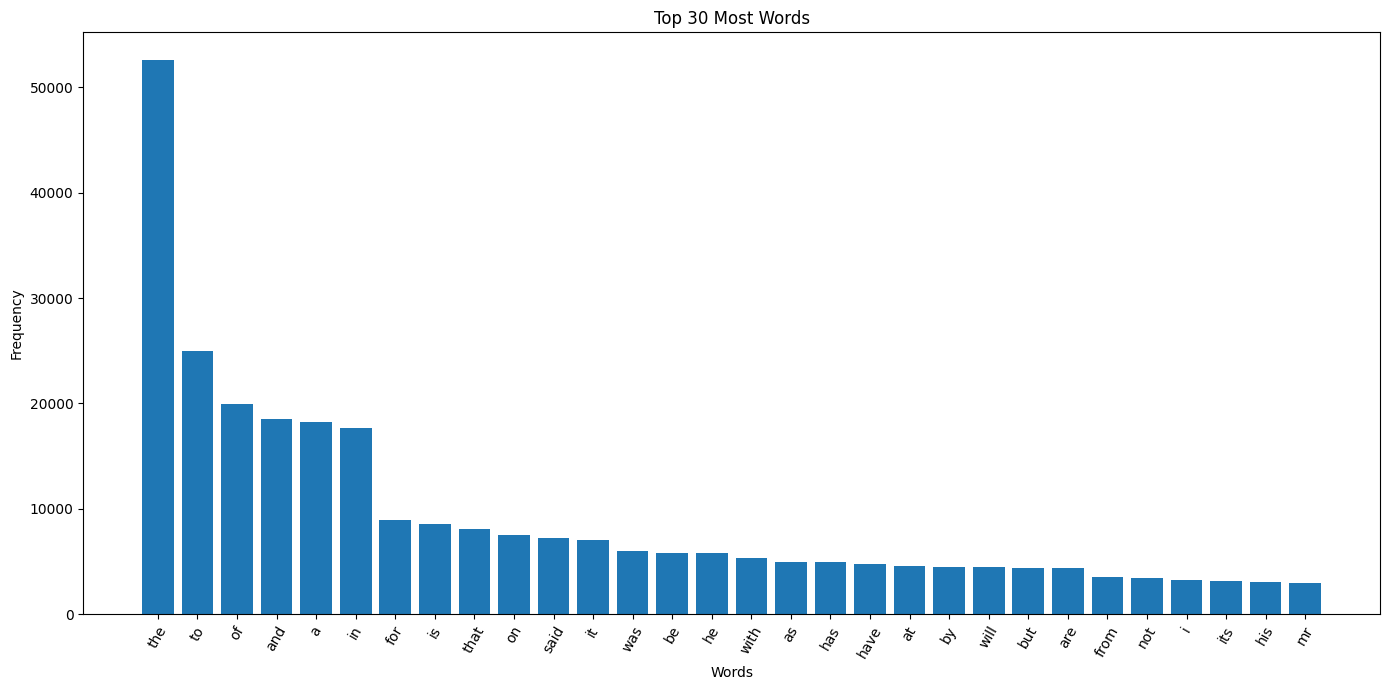


Chart saved successfully.


In [3]:
import os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("processed_dataset.csv")


print("Question 8")

print(f"Dataset Shape: {df.shape}")

all_text = " ".join(df["Processed_Text"].astype(str))
words = all_text.split()

print(f"\nTotal Number of Words: {len(words)}")
word_counter = Counter(words)
words_30 = word_counter.most_common(30)
print("\nTop 30 Most Words:\n")

for i, (word, count) in enumerate(words_30, start=1):
    print(f"{i:2d}. {word:<20} {count}")

word_names = []
for item in words_30:
    word_names.append(item[0])

word_counts = []
for item in words_30:
    word_counts.append(item[1])

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(14, 7))

plt.bar(word_names, word_counts)

plt.title("Top 30 Most Words")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.xticks(rotation=60)

plt.tight_layout()

plt.savefig("images/top30_words.png", dpi=300)

plt.show()

print("\nChart saved successfully.")

### Answer: Does knowing the counts of these words help us understand the topic of a news item?

Not really. If we look at the output above, the 30 most frequent words are almost all very common, generic words and connectives: `the`, `to`, `of`, `and`, `a`, `in`, `for`, `is`, `that`, `on`, and so on. These are called stopwords, and they show up a lot in basically every English text — it doesn't matter whether the article is about politics, sport, or technology. Even `said` and `mr`, which feel a bit more "news-like", are shared across all the news categories.

So just knowing how many times these words appear tells us almost nothing about the topic of the article. To actually understand the topic, we need to look at words that appear a lot in one article but are rare across the whole corpus (the TF-IDF idea from Question 1), or first remove the stopwords and then look at the remaining keywords.

## Question 9

Question 9
Dataset Shape: (2225, 3)

Total Characters: 4888298


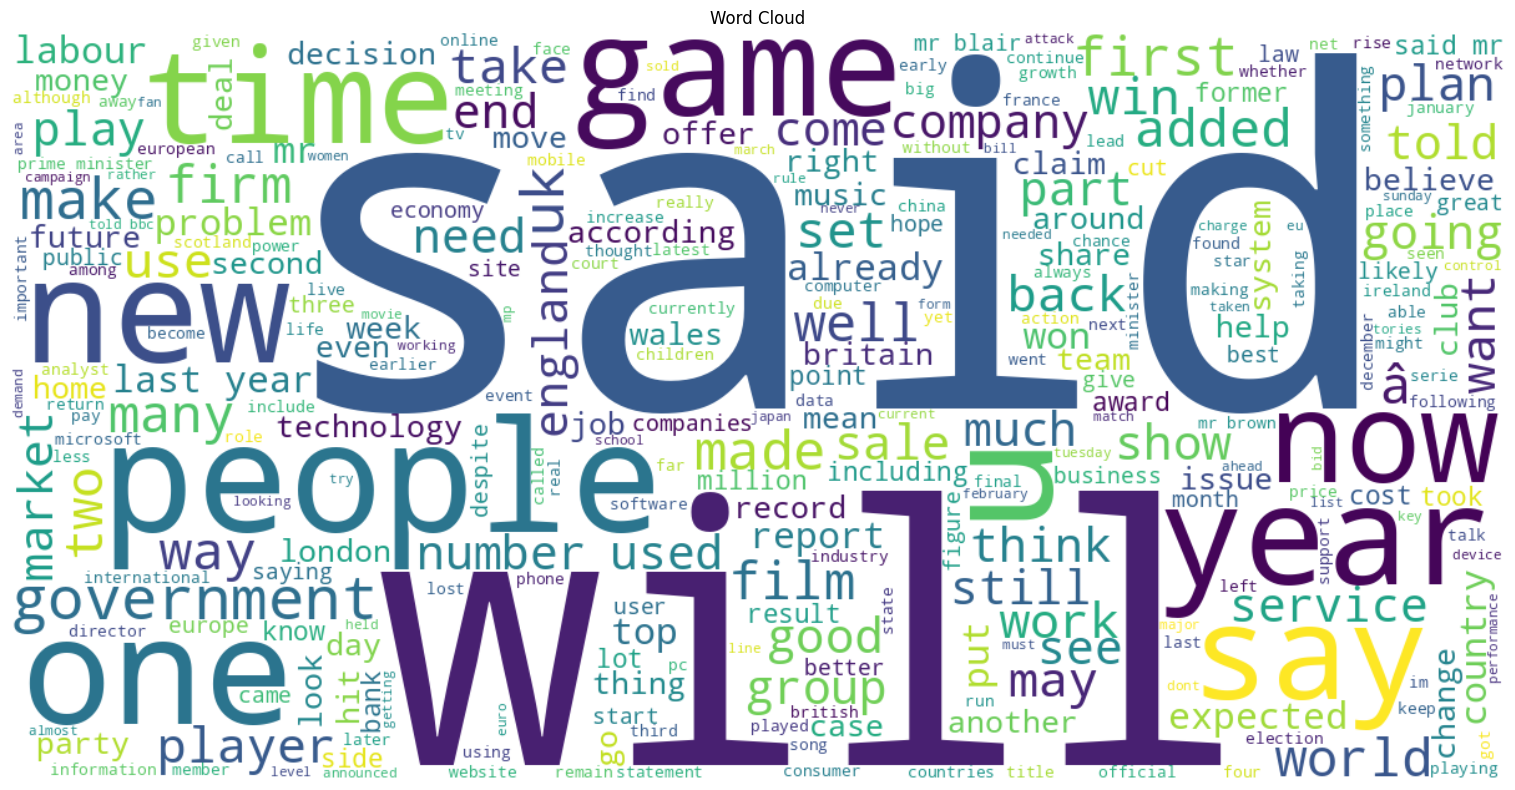


Word Cloud generated


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

df = pd.read_csv("processed_dataset.csv")

print("Question 9")


print(f"Dataset Shape: {df.shape}")

all_text = " ".join(df["Processed_Text"].astype(str))

print(f"\nTotal Characters: {len(all_text)}")


wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=300
).generate(all_text)


os.makedirs("images", exist_ok=True)

plt.figure(figsize=(16,8))

plt.imshow(wordcloud,interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud")

plt.tight_layout()

plt.savefig("images/wordcloud.png", dpi=300)

plt.show()

print("\nWord Cloud generated")

### Answer: How to read the word cloud, and what decides which words appear and how big they are

In a word cloud, each word is drawn with a size proportional to how often it appears: the more a word is repeated across all the texts, the bigger and bolder it is written, while rare words appear smaller. So at a glance we can see which words dominate the dataset.

The selection criterion works the same way. The `WordCloud` library first counts the frequency of every word, normalizes those counts relative to the most frequent word, then places only a limited number of the most frequent ones on the image (here with `max_words=300`), and sets each word's font size according to that normalized frequency. By default it also has a built-in stopword list that removes some of the very common words.

The important point is that since the only criterion is "frequency", exactly like in Question 8, the generic high-frequency words get the biggest size and are not necessarily the most meaningful words. That's why a word cloud is more of a quick visual overview of the data than a precise tool for understanding the topic.

## Question 11

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


print("Question 11")



bow_train = pd.read_csv("bag_of_words_train.csv")

print(f"Bag of Words (train) shape : {bow_train.shape}")

X = bow_train.values.astype(float)


scaler = StandardScaler()
X_std = scaler.fit_transform(X)

np.save("X_standardized.npy", X_std)

print("\nStandardization done (mean=0, std=1 per column).")
print(f"Standardized matrix shape : {X_std.shape}")

U, S, Vt = np.linalg.svd(X_std, full_matrices=True)

print("\nSVD Matrix Shapes:")
print(f"U  (documents x documents) : {U.shape}")
print(f"S  (singular values, 1D) : {S.shape}")
print(f"Vt (words x words) : {Vt.shape}")


np.save("U.npy", U)
np.save("S.npy", S)
np.save("Vt.npy", Vt)



Question 11
Bag of Words (train) shape : (2000, 52)

Standardization done (mean=0, std=1 per column).
Standardized matrix shape : (2000, 52)



SVD Matrix Shapes:
U  (documents x documents) : (2000, 2000)
S  (singular values, 1D) : (52,)
Vt (words x words) : (52, 52)


## Question 12

Question 12


Standardized matrix shape : (2000, 52)
Number of singular values : 52


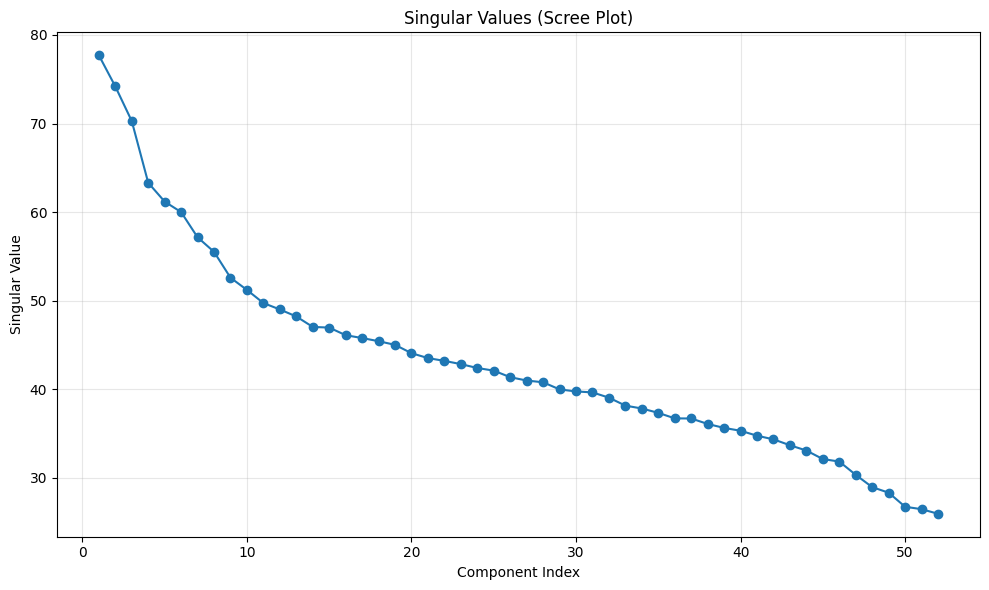


Suggested elbow point (threshold): keep top 11 components
Singular value at the elbow : 49.7241


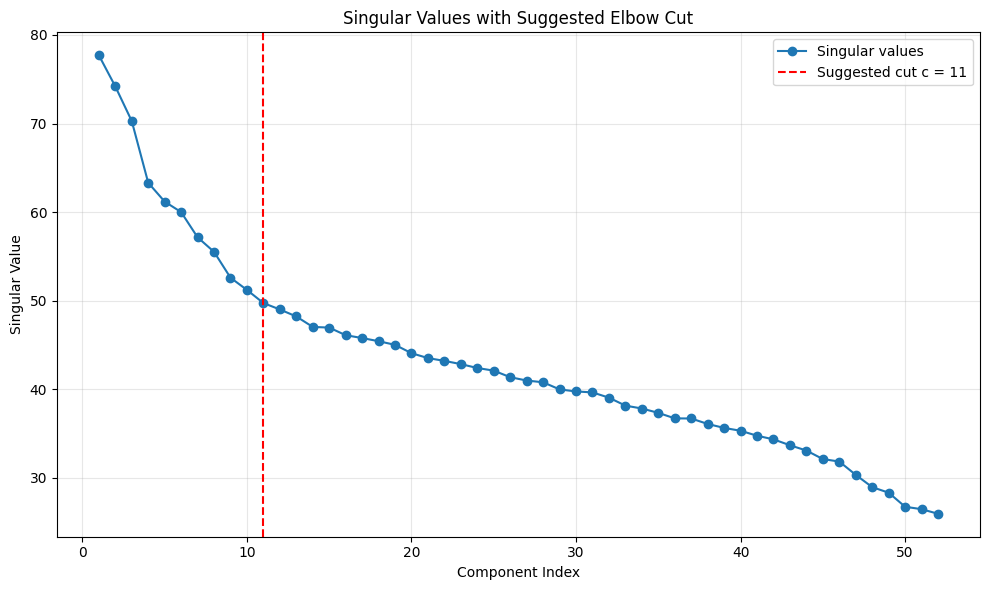


Truncated SVD Matrix Shapes:
U_trunc  (documents x concepts) : (2000, 11)
S_trunc  (concepts, 1D) : (11,)
Vt_trunc (concepts x words) : (11, 52)

Error:
Absolute : 248.9213
Relative : 77.1872%


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

print("Question 12")

X_std = np.load("X_standardized.npy")
U = np.load("U.npy")
S = np.load("S.npy")
Vt = np.load("Vt.npy")

print(f"Standardized matrix shape : {X_std.shape}")
print(f"Number of singular values : {S.shape[0]}")

os.makedirs("images", exist_ok=True)

ranks = np.arange(1, len(S) + 1)

plt.figure(figsize=(10, 6))
plt.plot(ranks, S, marker="o")
plt.title("Singular Values (Scree Plot)")
plt.xlabel("Component Index")
plt.ylabel("Singular Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/singular_values.png", dpi=300)
plt.show()


x1, y1 = ranks[0], S[0]
x2, y2 = ranks[-1], S[-1]

num = np.abs((y2 - y1) * ranks - (x2 - x1) * S + (x2 * y1 - y2 * x1))
den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
distances = num / den

index = int(np.argmax(distances))
c = index + 1  

print(f"\nSuggested elbow point (threshold): keep top {c} components")
print(f"Singular value at the elbow : {S[index]:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(ranks, S, marker="o", label="Singular values")
plt.axvline(c, color="red", linestyle="--", label=f"Suggested cut c = {c}")
plt.title("Singular Values with Suggested Elbow Cut")
plt.xlabel("Component Index")
plt.ylabel("Singular Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/elbow.png", dpi=300)
plt.show()


U_trunc = U[:, :c]
S_trunc = S[:c]
Vt_trunc = Vt[:c, :]

print("\nTruncated SVD Matrix Shapes:")
print(f"U_trunc  (documents x concepts) : {U_trunc.shape}")
print(f"S_trunc  (concepts, 1D) : {S_trunc.shape}")
print(f"Vt_trunc (concepts x words) : {Vt_trunc.shape}")


X_approx = U_trunc @ np.diag(S_trunc) @ Vt_trunc

reconstruction_error_abs = np.linalg.norm(X_std - X_approx, ord="fro")
reconstruction_error_rel = reconstruction_error_abs / np.linalg.norm(X_std, ord="fro")

print("\nError:")
print(f"Absolute : {reconstruction_error_abs:.4f}")
print(f"Relative : {reconstruction_error_rel:.4%}")


np.save("U_trunc.npy", U_trunc)
np.save("S_trunc.npy", S_trunc)
np.save("Vt_trunc.npy", Vt_trunc)



## Question 13

In [7]:
import numpy as np


def randomized_svd(A, rank, n_oversamples=10, n_iter=4, random_state=None):
    
    rng = np.random.default_rng(random_state)
    d, n = A.shape
    k = min(rank + n_oversamples, n)

    Omega = rng.standard_normal(size=(n, k))
    
    Y = A @ Omega
    
    for _ in range(n_iter):
        Q, _ = np.linalg.qr(Y)
        Z = A.T @ Q
        Q_z, _ = np.linalg.qr(Z)
        Y = A @ Q_z
    
    Q, _ = np.linalg.qr(Y)
    
    B = Q.T @ A
    
    U_b, S, Vt = np.linalg.svd(B, full_matrices=False)
    
    U = Q @ U_b
    
    U = U[:, :rank]
    S = S[:rank]
    Vt = Vt[:rank, :]

    return U, S, Vt

if __name__ == "__main__":

    print("Question 13")

    rng = np.random.default_rng(42)
    test_matrix = rng.standard_normal((200, 50))
    test_rank = 10

    U_exact, S_exact, Vt_exact = np.linalg.svd(test_matrix, full_matrices=False)
    U_rand, S_rand, Vt_rand = randomized_svd(
        test_matrix, rank=test_rank, n_oversamples=10, n_iter=4, random_state=0
    )

    print(f"Top {test_rank} singular values (exact SVD) : {np.round(S_exact[:test_rank], 4)}")
    print(f"Top {test_rank} singular values (randomized SVD): {np.round(S_rand, 4)}")
    print(f"Max absolute difference : " f"{np.max(np.abs(S_exact[:test_rank] - S_rand)):.6f}")

    X_std = np.load("X_standardized.npy")
    S_trunc = np.load("S_trunc.npy")
    c = len(S_trunc)  

    print(f"Standardized matrix shape : {X_std.shape}")
    print(f"Target rank : {c}")

    U_r, S_r, Vt_r = randomized_svd(X_std, rank=c, n_oversamples=10, n_iter=4, random_state=0)

    print("\nRandomized SVD Matrix Shapes:")
    print(f"U_random  (documents x concepts) : {U_r.shape}")
    print(f"S_random  (concepts, 1D) : {S_r.shape}")
    print(f"Vt_random (concepts x words) : {Vt_r.shape}")

    print("\nSingular values comparison (Truncated SVD vs Randomized SVD):")
    print(f"{'Idx':<5}{'Truncated SVD':<18}{'Randomized SVD':<18}")
    for i in range(c):
        print(f"{i+1:<5}{S_trunc[i]:<18.4f}{S_r[i]:<18.4f}")

    np.save("U_randomized.npy", U_r)
    np.save("S_randomized.npy", S_r)
    np.save("Vt_randomized.npy", Vt_r)



Question 13
Top 10 singular values (exact SVD) : [20.6325 20.324  19.5839 19.3638 19.0404 18.8274 18.5595 17.879  17.6678
 17.4087]
Top 10 singular values (randomized SVD): [20.6286 20.3055 19.5678 19.3568 19.0274 18.7788 18.5399 17.8284 17.5739
 17.3722]
Max absolute difference : 0.093848
Standardized matrix shape : (2000, 52)
Target rank : 11

Randomized SVD Matrix Shapes:
U_random  (documents x concepts) : (2000, 11)
S_random  (concepts, 1D) : (11,)
Vt_random (concepts x words) : (11, 52)

Singular values comparison (Truncated SVD vs Randomized SVD):
Idx  Truncated SVD     Randomized SVD    
1    77.7089           77.7082           
2    74.1867           74.1852           
3    70.2745           70.2701           
4    63.3089           63.2850           
5    61.1806           61.1638           
6    59.9960           59.9604           
7    57.1478           57.0536           
8    55.5075           55.2626           
9    52.5866           52.1433           
10   51.2052        

## Question 14

In [8]:
import time
import numpy as np

# randomized_svd is defined in the Question 13 cell above; run that cell first so the
# function is available here (no dependency on the external q13.py file).

print("Question 14")

X_std = np.load("X_standardized.npy")

U_trunc = np.load("U_trunc.npy")
S_trunc = np.load("S_trunc.npy")
Vt_trunc = np.load("Vt_trunc.npy")

U_rand = np.load("U_randomized.npy")
S_rand = np.load("S_randomized.npy")
Vt_rand = np.load("Vt_randomized.npy")

c = len(S_trunc)

print(f"Standardized matrix shape : {X_std.shape}")
print(f"Rank used (elbow, Q12) : {c}")

X_approx_trunc = U_trunc @ np.diag(S_trunc) @ Vt_trunc
err_trunc_abs = np.linalg.norm(X_std - X_approx_trunc, ord="fro")
err_trunc_rel = err_trunc_abs / np.linalg.norm(X_std, ord="fro")

X_approx_rand = U_rand @ np.diag(S_rand) @ Vt_rand
err_rand_abs = np.linalg.norm(X_std - X_approx_rand, ord="fro")
err_rand_rel = err_rand_abs / np.linalg.norm(X_std, ord="fro")

print("Error Comparison")
print(f"{'Method':<20}{'Absolute (Frobenius)':<25}{'Relative':<10}")
print(f"{'Truncated SVD':<20}{err_trunc_abs:<25.4f}{err_trunc_rel:.4%}")
print(f"{'Randomized SVD':<20}{err_rand_abs:<25.4f}{err_rand_rel:.4%}")
print(f"\nDifference in relative error : {abs(err_rand_rel - err_trunc_rel):.4%}")

print("\nRuntime Comparison (on our dataset)")

n_runs = 5

start = time.perf_counter()
for _ in range(n_runs):
    np.linalg.svd(X_std, full_matrices=True)
time_exact = (time.perf_counter() - start) / n_runs

start = time.perf_counter()
for _ in range(n_runs):
    randomized_svd(X_std, rank=c, n_oversamples=10, n_iter=4, random_state=0)
time_random = (time.perf_counter() - start) / n_runs

print(f"Exact / Full SVD   average time : {time_exact*1000:.2f} ms")
print(f"Randomized SVD     average time : {time_random*1000:.2f} ms")
print(f"Speedup (exact / randomized)    : {time_exact / time_random:.2f}x")

print("Runtime Comparison (large synthetic matrix, for scale intuition)")

rng = np.random.default_rng(0)
big_matrix = rng.standard_normal((8000, 500))
big_rank = 20

start = time.perf_counter()
np.linalg.svd(big_matrix, full_matrices=False)
time_exact_big = time.perf_counter() - start

start = time.perf_counter()
randomized_svd(big_matrix, rank=big_rank, n_oversamples=10, n_iter=4, random_state=0)
time_random_big = time.perf_counter() - start

print(f"Matrix shape : {big_matrix.shape}, target rank = {big_rank}")
print(f"Exact SVD time : {time_exact_big:.3f} s")
print(f"Randomized SVD time : {time_random_big:.3f} s")
print(f"Speedup (exact / randomized) : {time_exact_big / time_random_big:.2f}x")


Question 14
Standardized matrix shape : (2000, 52)
Rank used (elbow, Q12) : 11


Error Comparison
Method              Absolute (Frobenius)     Relative  
Truncated SVD       248.9213                 77.1872%
Randomized SVD      249.3666                 77.3253%

Difference in relative error : 0.1381%

Runtime Comparison (on our dataset)


Exact / Full SVD   average time : 275.42 ms
Randomized SVD     average time : 43.31 ms
Speedup (exact / randomized)    : 6.36x
Runtime Comparison (large synthetic matrix, for scale intuition)


Matrix shape : (8000, 500), target rank = 20
Exact SVD time : 1.288 s
Randomized SVD time : 0.208 s
Speedup (exact / randomized) : 6.19x


### Discussion: Truncated SVD vs Randomized SVD at internet scale

On our dataset (2000 x 52), the two methods produce almost identical
reconstruction errors (see comparison above) - the randomized method
loses very little accuracy despite only needing to look at a few
random projections of the data instead of factorizing the full
matrix.

If our dataset consisted of all texts on the internet, the
document-word matrix would be enormous (millions/billions of rows,
a very large vocabulary of columns). Exact/Truncated SVD needs
O(d * n * min(d, n)) time and full O(d * n) memory to even start,
which quickly becomes infeasible at that scale. Randomized SVD only
requires a small number of matrix-vector products with the (often
sparse) data matrix plus a tiny SVD of a much smaller projected
matrix, so its cost scales roughly linearly in the data size instead
of quadratically/cubically, and it also parallelizes/streams well.

For this reason, at internet scale we would recommend Randomized
SVD: it gives a reconstruction error that is close enough to the
exact/truncated solution for practical purposes (as shown above),
while being dramatically cheaper in both time and memory - the
scale of the speedup here already grows noticeably with the size of
the synthetic large matrix above, and this gap widens further as the
matrix grows toward internet scale.

## Question 15

Question 15
Vt_trunc shape : (11, 52)
Number of components : 11
Vocabulary size : 52
Top 5 words per component (by magnitude)

Component 1:
  election        weight = +0.3156
  labour          weight = +0.3041
  technology      weight = -0.2656
  mobile          weight = -0.2614
  digital         weight = -0.2506



Component 2:
  government      weight = -0.2659
  election        weight = -0.2526
  labour          weight = -0.2470
  tax             weight = -0.2140
  work            weight = -0.2132



Component 3:
  time            weight = +0.2987
  play            weight = +0.2957
  win             weight = +0.2934
  game            weight = +0.2858
  won             weight = +0.2295



Component 4:
  artist          weight = -0.3629
  music           weight = -0.3521
  won             weight = -0.3449
  film            weight = -0.2807
  game            weight = +0.2666



Component 5:
  deal            weight = +0.2795
  company         weight = +0.2514
  money           weight = +0.2419
  film            weight = -0.2375
  mobile          weight = -0.2332


...


Component 8:
  firm            weight = +0.2917
  director        weight = +0.2690
  party           weight = +0.2666
  company         weight = +0.2583
  government      weight = -0.2466



Component 9:
  money           weight = +0.3855
  law             weight = -0.3624
  home            weight = -0.3280
  club            weight = +0.2842
  tax             weight = +0.2441



Component 10:
  club            weight = +0.3571
  new             weight = +0.3197
  home            weight = +0.3029
  deal            weight = +0.2884
  online          weight = -0.2760



Component 11:
  computer        weight = -0.3335
  number          weight = +0.3098
  old             weight = -0.3053
  government      weight = +0.2863
  technology      weight = -0.2470



Saved 11 component bar charts to images/component_<i>_top_words.png


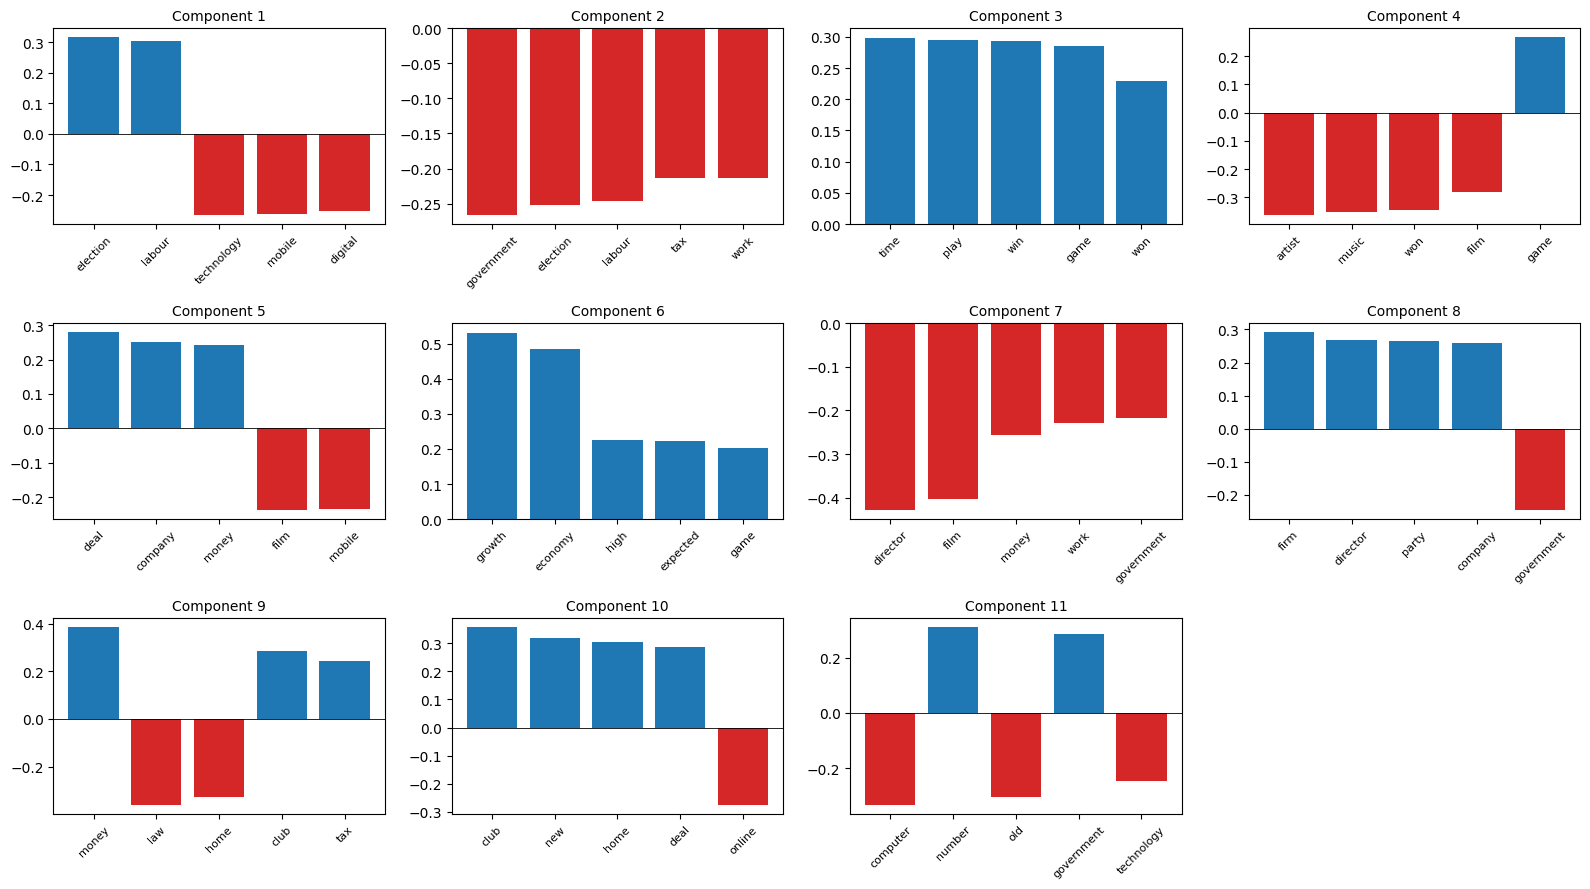

Discussion: guessing the latent meaning of each component

Each component below is labeled with the theme its top-5 words
overlap with most (based on a rough grouping of our vocabulary into
politics / sport / technology / business / entertainment). This is
only a heuristic to help interpret the components - SVD components
are not required to align with human-defined categories, only to
capture directions of maximum variance in the data, so some
components mix words from different themes or are dominated by
generic words and are harder to label cleanly.

Component  1 - words: ['election', 'labour', 'technology', 'mobile', 'digital']
-> looks like a 'Technology' concept (3/5 words match)

Component  2 - words: ['government', 'election', 'labour', 'tax', 'work']
-> looks like a 'Politics' concept (4/5 words match)

Component  3 - words: ['time', 'play', 'win', 'game', 'won']
-> looks like a 'Sport' concept (4/5 words match)

Component  4 - words: ['artist', 'music', 'won', 'film', 'game']

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Question 15")

Vt_trunc = np.load("Vt_trunc.npy")
words = pd.read_csv("words.csv").iloc[:, 0].astype(str).tolist()

num_components, num_words = Vt_trunc.shape
print(f"Vt_trunc shape : {Vt_trunc.shape}")
print(f"Number of components : {num_components}")
print(f"Vocabulary size : {num_words}")

os.makedirs("images", exist_ok=True)

top_k = 5
component_top_words = []  

print("Top 5 words per component (by magnitude)")

for j in range(num_components):
    weights = Vt_trunc[j, :]
    top_indices = np.argsort(-np.abs(weights))[:top_k]

    top_words = []
    top_weights = []

    for i in top_indices:
        top_words.append(words[i])
        top_weights.append(weights[i])

    component_top_words.append(top_words)

    print(f"\nComponent {j + 1}:")
    for w, val in zip(top_words, top_weights):
        sign = "+" if val >= 0 else "-"
        print(f"  {w:<15} weight = {sign}{abs(val):.4f}")

    
    plt.figure(figsize=(8, 4))
    colors = ["tab:blue" if v >= 0 else "tab:red" for v in top_weights]
    plt.bar(top_words, top_weights, color=colors)
    plt.axhline(0, color="black", linewidth=0.8)
    plt.title(f"Component {j + 1} - Top {top_k} Words")
    plt.ylabel("Weight")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"images/component_{j + 1}_top_words.png", dpi=200)
    plt.close()

print(f"\nSaved {num_components} component bar charts to images/component_<i>_top_words.png")


cols = 4
rows = int(np.ceil(num_components / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
axes = np.array(axes).reshape(-1)

for j in range(num_components):
    weights = Vt_trunc[j, :]
    top_indices = np.argsort(-np.abs(weights))[:top_k]
    top_words = [words[i] for i in top_indices]
    top_weights = [weights[i] for i in top_indices]
    colors = ["tab:blue" if v >= 0 else "tab:red" for v in top_weights]

    ax = axes[j]
    ax.bar(top_words, top_weights, color=colors)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(f"Component {j + 1}", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)


for j in range(num_components, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("images/all_components_top_words.png", dpi=200)
plt.show()

themes = {
    "Politics": {"election", "government", "labour", "minister", "party", "law", "tax", "uk"},
    "Sport": {"win", "won", "match", "play", "club", "game"},
    "Technology": {"mobile", "phone", "digital", "online", "computer", "technology",
                   "user", "service", "market", "industry"},
    "Business": {"company", "firm", "market", "economy", "growth", "deal", "money",
                 "million", "sale", "office", "group", "new", "help", "expected", "number"},
    "Entertainment": {"film", "music", "director", "artist", "record"},
}

print("Discussion: guessing the latent meaning of each component")

print("""
Each component below is labeled with the theme its top-5 words
overlap with most (based on a rough grouping of our vocabulary into
politics / sport / technology / business / entertainment). This is
only a heuristic to help interpret the components - SVD components
are not required to align with human-defined categories, only to
capture directions of maximum variance in the data, so some
components mix words from different themes or are dominated by
generic words and are harder to label cleanly.
""")

for j, top_words in enumerate(component_top_words):
    top_words_set = set(top_words)
    scores = {theme: len(top_words_set & vocab) for theme, vocab in themes.items()}
    best_theme = max(scores, key=scores.get)
    best_score = scores[best_theme]

    if best_score == 0:
        guess = "no clear single theme (mixed / generic words)"
    else:
        guess = f"looks like a '{best_theme}' concept ({best_score}/{top_k} words match)"

    print(f"Component {j + 1:>2} - words: {top_words}")
    print(f"-> {guess}\n")


## Question 16

In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances

print("Question 16")

Vt = np.load("Vt_trunc.npy")

print(f"Vt shape : {Vt.shape}")

vocabulary = pd.read_csv("words.csv").iloc[:, 0].astype(str).tolist()

word_to_index = {
    word: idx
    for idx, word in enumerate(vocabulary)
}

word_pairs = [
    ("mobile", "technology"),
    ("director", "film"),
    ("win", "won"),
    ("play", "game"),
    ("play", "law"),
    ("government", "music")
]

print("\nResults\n")

print(f"{'Word 1':<15}{'Word 2':<15}{'Cosine':<15}{'Euclidean'}")

for w1, w2 in word_pairs:
    if w1 not in word_to_index or w2 not in word_to_index:
        print(f"{w1:<15}{w2:<15}Not Found")
        continue

    idx1 = word_to_index[w1]
    idx2 = word_to_index[w2]

    vec1 = Vt[:, idx1].reshape(1, -1)
    vec2 = Vt[:, idx2].reshape(1, -1)

    cos = cosine_similarity(vec1, vec2)[0, 0]

    dist = euclidean_distances(vec1, vec2)[0, 0]

    print(
        f"{w1:<15}"
        f"{w2:<15}"
        f"{cos:<15.4f}"
        f"{dist:.4f}"
    )


Question 16
Vt shape : (11, 52)

Results

Word 1         Word 2         Cosine         Euclidean
mobile         technology     0.5804         0.4682
director       film           0.9852         0.1052
win            won            0.7129         0.3345
play           game           0.9488         0.1634
play           law            -0.2589        0.7779
government     music          0.0940         0.7558


### Answer: Interpreting the cosine similarity and Euclidean distance results

Reading the output above (remember that in the latent space, a cosine close to 1 means the two words are related/similar, and a small Euclidean distance says the same thing):

- **director and film** (cosine 0.99, distance 0.11): the highest similarity. This makes sense, since these two words almost always appear together in texts about cinema.
- **play and game** (cosine 0.95, distance 0.16): very close, because both show up in a sport/games context.
- **win and won** (cosine 0.71, distance 0.33): a good similarity. Interestingly, without knowing that these are just two tenses of the same verb, the model figured out they are related purely from how they co-occur.
- **mobile and technology** (cosine 0.58, distance 0.47): a moderate similarity. They are related but not very strongly; `mobile` is a narrower sub-area of the whole of `technology`.
- **play and law** (cosine -0.26, distance 0.78): a negative similarity. These two belong to different worlds (sport/entertainment vs. politics/law), and the model placed them far apart.
- **government and music** (cosine 0.09, distance 0.76): close to zero, i.e. essentially unrelated and almost orthogonal. Again this is correct, since politics and music rarely appear in the same context.

Summary: wherever the cosine is high the Euclidean distance is small, and vice versa; the two measures tell the same story and show that the latent space managed to learn the semantic relationships between words just from how they co-occur in the texts.


## Question 17

Question 17


Document Vector Shape : (2000, 11)
Word Vector Shape : (52, 11)
Original document 222 is at training row 791

Selected Document : 222
Number of Words : 509

Top Similar Words

          Word  Similarity  Frequency
44         tax    0.866965         11
11    election    0.804995          4
24      labour    0.770390          3
38       party    0.631797          2
36         old    0.441925          1
29    minister    0.425034          0
31       money    0.409759          1
46        time    0.379501          4
10     economy    0.371137          2
20        help    0.367397          0
51        work    0.319211          0
17  government    0.263323          1
40        play    0.224961          1
6      country    0.214649          0
3         club    0.168311          0
37      online    0.153669          0
12    expected    0.122587          0
19      growth    0.111799          0
16        game    0.104458          0
7         deal    0.086158          0

Top Frequent Words

     

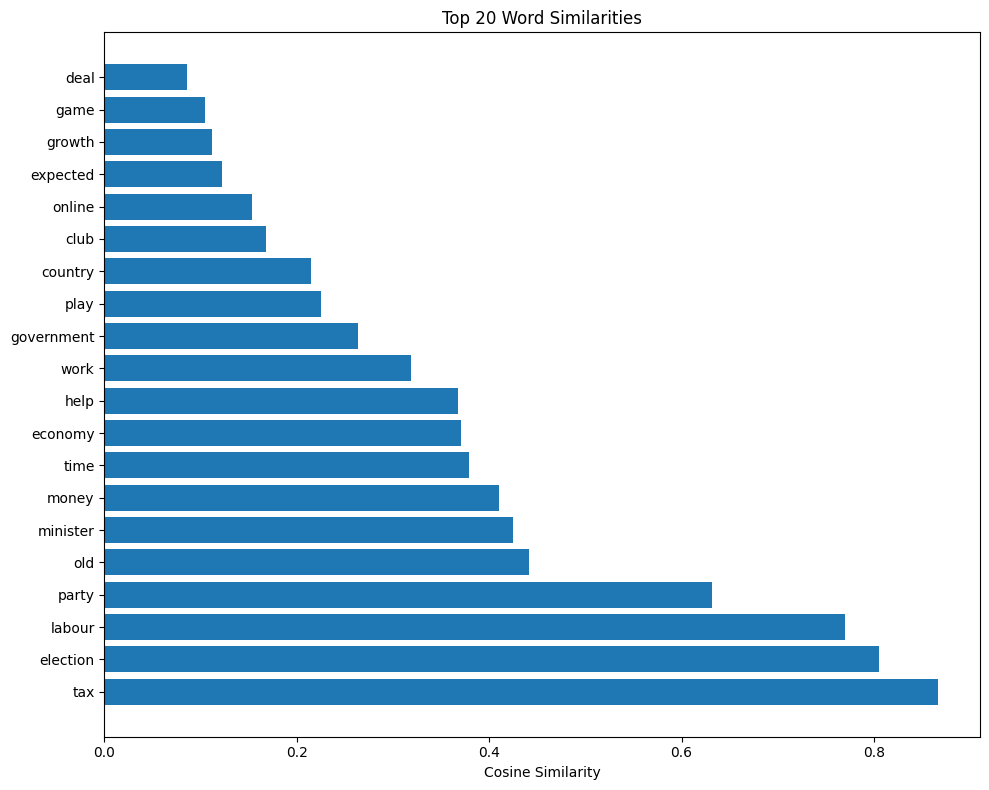

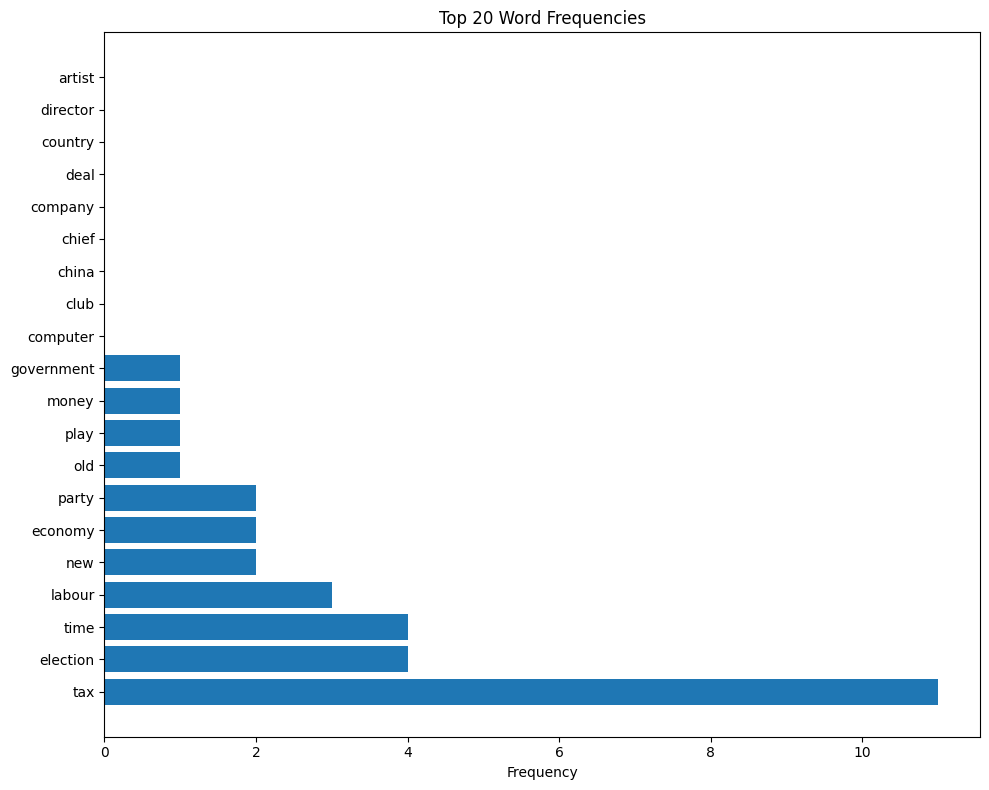

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

print("Question 17")

DOCUMENT_INDEX = 222  # last 3 digits of student ID 403521222 -> original document 222

df = pd.read_csv("processed_dataset.csv")             # full dataset, ORIGINAL order
df_train = pd.read_csv("processed_dataset_train.csv")  # shuffled training rows (+ orig_index)
words = pd.read_csv("words.csv")

U = np.load("U_trunc.npy")
S = np.load("S_trunc.npy")
Vt = np.load("Vt_trunc.npy")

vocabulary = words.iloc[:, 0].astype(str).tolist()

document_vectors = U @ np.diag(S)

word_vectors = Vt.T

# The training rows were shuffled before the SVD, so the rows of U_trunc do not line
# up with the original document order. Find where the original document 222 now sits
# inside the shuffled training set and use that row's latent vector.
train_pos = int(df_train.index[df_train["orig_index"] == DOCUMENT_INDEX][0])

print(f"Document Vector Shape : {document_vectors.shape}")
print(f"Word Vector Shape : {word_vectors.shape}")
print(f"Original document {DOCUMENT_INDEX} is at training row {train_pos}")

document_vector = document_vectors[train_pos].reshape(1, -1)

document_text = df.loc[DOCUMENT_INDEX, "Processed_Text"]

tokens = document_text.split()

print(f"\nSelected Document : {DOCUMENT_INDEX}")
print(f"Number of Words : {len(tokens)}")

from collections import Counter

counter = Counter(tokens)

similarities = []
frequencies = []

for word in vocabulary:

    word_to_index = {}
    for i,w in enumerate(vocabulary):
        word_to_index[w] = i

    idx = word_to_index[word]

    word_vector = word_vectors[idx].reshape(1, -1)

    score = cosine_similarity(document_vector, word_vector)[0, 0]

    similarities.append(score)

    frequencies.append(counter.get(word, 0))


result = pd.DataFrame({
    "Word": vocabulary,
    "Similarity": similarities,
    "Frequency": frequencies
})

top_similarity = result.sort_values(
    by="Similarity",
    ascending=False
).head(20)

top_frequency = result.sort_values(
    by="Frequency",
    ascending=False
).head(20)

print("\nTop Similar Words\n")

print(top_similarity)

print("\nTop Frequent Words\n")

print(top_frequency)

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10,8))

plt.barh(

    top_similarity["Word"],
    top_similarity["Similarity"]

)

plt.title("Top 20 Word Similarities")

plt.xlabel("Cosine Similarity")

plt.tight_layout()

plt.savefig(

    "images/document_similarity.png",

    dpi=300

)

plt.show()

plt.figure(figsize=(10,8))

plt.barh(

    top_frequency["Word"],
    top_frequency["Frequency"]

)

plt.title("Top 20 Word Frequencies")

plt.xlabel("Frequency")

plt.tight_layout()

plt.savefig(

    "images/document_frequency.png",
    dpi=300

)

plt.show()

result.to_csv(

    "document_word_similarity.csv",
    index=False

)


### Answer: Comparing the two charts (cosine similarity vs. frequency)

Comparing the two charts for document 222, they both point to the same conclusion about the topic: this document is a politics / economy news item. The words that stand out — `tax`, `election`, `labour`, `party`, `economy`, `government` — sit near the top of both the similarity chart and the frequency chart. In fact `tax` is #1 in both: it is the most frequent word (11 times) and also the most similar to the document's latent vector (0.87).

But the two charts are not identical, and the differences are the interesting part:

- **Words that are similar but barely appear (or don't appear at all).** For example `minister` has a high similarity (0.43) but a frequency of 0 — it never literally occurs in the document. The latent space still marks it as relevant because it belongs to the same concept (politics: labour / party / government). This is exactly the semantic strength of LSI: it can connect a word to a document through meaning, not just literal matching.
- **Words that appear often but are not that relevant.** For example `time` occurs 4 times and `new` occurs twice, so they rank high on the frequency chart, but their cosine similarity is low (`time` ≈ 0.38, `new` ≈ 0.08). These are generic words that show up in many kinds of documents, so the latent space does not treat them as strong signals of the topic.

So the comparison shows the difference between the two views: **frequency only counts how many times a word is literally repeated in the document, while latent-space similarity measures how well a word fits the document's overall concept.** They agree on the core topical words (`tax`, `election`, `labour`, `party`), but similarity additionally surfaces related words that are absent (like `minister`) and pushes down common words that are present but uninformative (like `new` / `time`). This is why the latent-space score is a better measure of "what this document is really about" than raw word counts.


## Question 18

In [12]:
import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity

print("Question 18")

doc_id = 222  # original document (last 3 digits of student ID 403521222)

df = pd.read_csv("processed_dataset.csv")             # full dataset, ORIGINAL order
df_train = pd.read_csv("processed_dataset_train.csv")  # shuffled training rows (+ orig_index)

U = np.load("U_trunc.npy")
S = np.load("S_trunc.npy")

doc_vectors = U @ np.diag(S)

# rows of U_trunc follow the shuffled training order; map original document ids to
# their position in that order (and back again for reporting).
orig_index = df_train["orig_index"].values
query_pos = int(df_train.index[df_train["orig_index"] == doc_id][0])

query = doc_vectors[query_pos].reshape(1, -1)

scores = cosine_similarity(query, doc_vectors)[0]

order = np.argsort(scores)[::-1]

order = order[order != query_pos]

top_positions = order[:10]

result = []

for pos in top_positions:

    orig_i = int(orig_index[pos])

    result.append({
        "Document": orig_i,
        "Similarity": scores[pos],
        "Label": df.loc[orig_i, "Label"]
    })

result = pd.DataFrame(result)

print("\nMost Similar Documents\n")
print(result)

result.to_csv("latent_search_result.csv", index=False)

print("\nQuery Document")

print(df.loc[doc_id, "Processed_Text"])


for pos in top_positions:

    orig_i = int(orig_index[pos])

    print(f"\nDocument {orig_i}")
    print(f"Similarity : {scores[pos]:.4f}")
    print(f"Label : {df.loc[orig_i, 'Label']}")
    print(df.loc[orig_i, "Processed_Text"])


Question 18



Most Similar Documents

   Document  Similarity  Label
0       392    0.943975      0
1       119    0.934581      0
2        15    0.920339      0
3       304    0.907367      0
4       132    0.900230      0
5       228    0.894575      0
6       326    0.889861      0
7       312    0.870978      0
8       411    0.866844      0
9        75    0.853007      0

Query Document
defection timed to hit tax pledge with impeccable and preciselycalculated timing tory defector robert jackson and his new labour bosses have attempted to overshadow michael howards latest announcement on taxation and spending with just about everyone in westminster now working towards a may general election mr howard is eager to map out some clear and distinctive policies aimed at finally shifting the tories resolutely depressing poll showings the big idea is his â£35bn savings on waste and bureaucracy which mr howard has pledged to plough back into public services and tax cuts and it was virtually certain his 

### Answer: The advantage of searching in the latent space

**1) Recognizing a relevant text even when the exact word is missing.** In the bag-of-words space, searching for the word `technology` only finds texts that literally contain the word `technology`; a text that instead uses `mobile` and `digital` gets a score of zero, because it has no direct word overlap. In the latent space, though, every text and every word becomes a vector in a space of "concepts". Since words like `technology`, `mobile` and `digital` co-occur in many texts, SVD places them along a shared conceptual direction (say, a "technology" concept), so their vectors end up close to each other (exactly what we saw in Question 16, where `mobile` and `technology` had a positive cosine). As a result, a text full of `mobile` and `digital` has a latent vector that lands near the `technology` direction and is correctly recognized as relevant, even if the word `technology` never appears in it. This is precisely the semantic advantage of LSI.

**2) The computational-cost advantage.** In the bag-of-words space, each text is a vector whose length equals the whole vocabulary size (here 52 words, but in a real application it can be tens or hundreds of thousands of words), and it is also very sparse. After Truncated SVD, each text is represented by just a `c`-dimensional vector (here `c=11`). So:

- To measure similarity, instead of working with vectors of thousands of dimensions, we only compare a handful of dimensions, and each cosine computation becomes much cheaper.
- The memory needed to store the vectors also drops sharply (a small dense matrix instead of a huge sparse one).

The code cell above does exactly this: to find documents similar to document 222, instead of comparing in the 52-dimensional bag-of-words space, we compared the 11-dimensional latent vectors with cosine similarity and quickly found the nearest documents.

## Question 19

Question 19


Train documents shape : (2000, 4)
U_trunc shape : (2000, 11)
S_trunc shape : (11,)
Document vectors shape : (2000, 11)
Politics        (381 train docs) : [ 1.825 -1.229  0.605  0.133 -0.365 -0.478 -0.049 -0.243 -0.218  0.13
  0.221]
Sport           (455 train docs) : [ 0.008  1.44   0.756  0.467  0.19   0.135  0.418 -0.147  0.331  0.371
 -0.091]
Technology      (359 train docs) : [-2.003 -1.009 -0.147  0.592 -0.468 -0.231  0.021 -0.003 -0.109 -0.394
 -0.227]
Entertainment   (340 train docs) : [-0.34   0.813  0.411 -1.218 -0.344 -0.256 -0.509  0.007  0.082 -0.231
  0.046]
Business        (465 train docs) : [ 0.291 -0.217 -1.422 -0.133  0.726  0.625 -0.014  0.34  -0.121  0.004
  0.051]


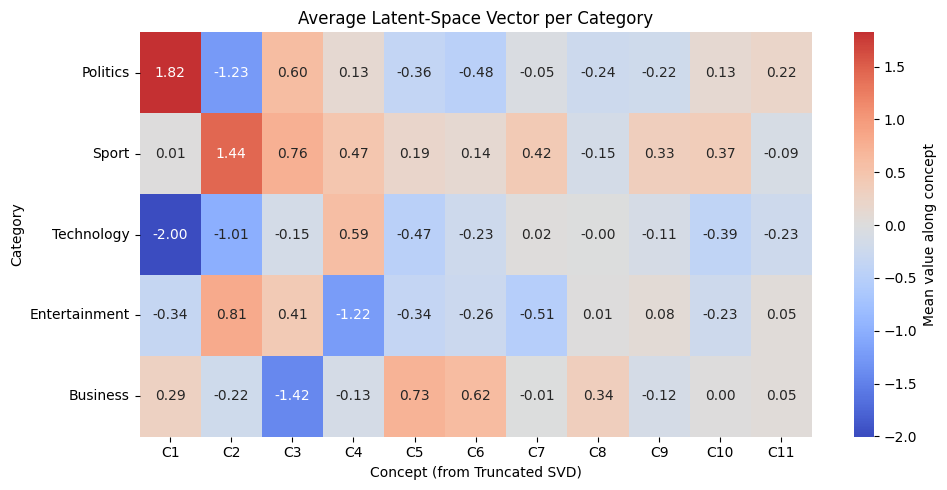

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("Question 19")

LABEL_NAMES = {
    0: "Politics",
    1: "Sport",
    2: "Technology",
    3: "Entertainment",
    4: "Business",
}

df_train = pd.read_csv("processed_dataset_train.csv")

U_trunc = np.load("U_trunc.npy")
S_trunc = np.load("S_trunc.npy")

print(f"Train documents shape : {df_train.shape}")
print(f"U_trunc shape : {U_trunc.shape}")
print(f"S_trunc shape : {S_trunc.shape}")


document_vectors = U_trunc @ np.diag(S_trunc)
num_concepts = document_vectors.shape[1]

print(f"Document vectors shape : {document_vectors.shape}")

labels = df_train["Label"].values

os.makedirs("images", exist_ok=True)

category_ids = sorted(LABEL_NAMES.keys())
category_means = np.zeros((len(category_ids), num_concepts))

for row, label in enumerate(category_ids):
    mask = labels == label
    n_docs = int(mask.sum())
    category_means[row] = document_vectors[mask].mean(axis=0)
    print(f"{LABEL_NAMES[label]:<15} ({n_docs} train docs) : "
          f"{np.round(category_means[row], 3)}")

cols = []
for i in range(num_concepts):
  cols.append(f"C{i + 1}")

m_df = pd.DataFrame(
    category_means,
    index=[LABEL_NAMES[i] for i in category_ids],
    columns=cols,
)

m_df.to_csv("category_mean_latent_vectors.csv")

plt.figure(figsize=(10, 5))
sns.heatmap(
    m_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Mean value along concept"},
)
plt.title("Average Latent-Space Vector per Category")
plt.xlabel("Concept (from Truncated SVD)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("images/category_mean_latent_heatmap.png", dpi=300)
plt.show()


### Proposed labeling / classification method

We cannot rely on manually interpreting what each latent concept
"means" (as attempted, only heuristically, in Question 15) - that
does not scale to real applications. Instead we use the category
mean vectors themselves as reference points ("centroids") directly
in the latent space, without needing to know what any individual
concept represents:

  1. Project every document (train or test) into the same c-dimensional
     latent space used above: doc_vector = u_i * diag(S_trunc), where
     u_i is the row of U (or, for a brand-new/test document, its bag-of-
     words vector standardized with the SAME scaler fitted on the train
     set and then projected with doc_vector = bow_std @ Vt_trunc.T).
  2. For each of the 5 category centroids computed above, compute the
     Cosine Similarity (or, equivalently, the Euclidean Distance) between
     the document's latent vector and every centroid.
  3. Assign the document to the category whose centroid has the highest
     Cosine Similarity (lowest Euclidean Distance) to the document -
     i.e. a nearest-centroid classifier in latent space.

This "nearest centroid in latent space" approach is attractive because:
  - It only uses the *relative geometry* of the latent vectors (how
    close a document is to each category's average pattern), so it
    works even though we do not know the human-readable meaning of the
    individual concepts.
  - It is cheap: with c concepts and 5 categories, classifying a new
    document only costs a handful of dot products, instead of comparing
    against the full (much higher-dimensional and much larger) bag-of-
    words matrix.
  - It naturally generalizes: new documents just need to be embedded
    into the same latent space (via the fixed Vt_trunc / scaler learned
    on the training set) and compared to the 5 fixed centroids.

This method is implemented and evaluated on the held-out test set in
Question 20.

## Question 20

In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

print("Question 20")

LABEL_NAMES = {
    0: "Politics",
    1: "Sport",
    2: "Technology",
    3: "Entertainment",
    4: "Business",
}

bow_train = pd.read_csv("bag_of_words_train.csv")
bow_test = pd.read_csv("bag_of_words_test.csv")
df_test = pd.read_csv("processed_dataset_test.csv")

Vt_trunc = np.load("Vt_trunc.npy")

m_df = pd.read_csv("category_mean_latent_vectors.csv", index_col=0)

print(f"Test documents shape : {bow_test.shape}")
print(f"Vt_trunc shape : {Vt_trunc.shape}")
print(f"Centroids shape : {m_df.shape}")

scaler = StandardScaler()
scaler.fit(bow_train.values.astype(float))
X_test_std = scaler.transform(bow_test.values.astype(float))

test_vectors = X_test_std @ Vt_trunc.T

category_ids = sorted(LABEL_NAMES.keys())
centroids = m_df.loc[[LABEL_NAMES[i] for i in category_ids]].values

similarities = cosine_similarity(test_vectors, centroids)
nearest = np.argmax(similarities, axis=1)
predicted_labels = np.array(category_ids)[nearest]

true_labels = df_test["Label"].values
correct = predicted_labels == true_labels

overall_accuracy = correct.sum() / len(true_labels)

print("Nearest-centroid labeling results on the test set")
print(f"Overall Accuracy : {overall_accuracy:.4f}  ({correct.sum()}/{len(true_labels)})")

print("\nPer-category accuracy")
for label in category_ids:
    mask = true_labels == label
    n_docs = int(mask.sum())
    if n_docs == 0:
        print(f"{LABEL_NAMES[label]:<15} (0 test docs)   : N/A")
        continue
    n_correct = int(correct[mask].sum())
    acc = n_correct / n_docs
    print(f"{LABEL_NAMES[label]:<15} ({n_docs} test docs) : {acc:.4f}  ({n_correct}/{n_docs})")



Question 20
Test documents shape : (225, 52)
Vt_trunc shape : (11, 52)
Centroids shape : (5, 11)
Nearest-centroid labeling results on the test set
Overall Accuracy : 0.7689  (173/225)

Per-category accuracy
Politics        (36 test docs) : 0.7500  (27/36)
Sport           (56 test docs) : 0.9464  (53/56)
Technology      (42 test docs) : 0.7143  (30/42)
Entertainment   (46 test docs) : 0.6522  (30/46)
Business        (45 test docs) : 0.7333  (33/45)
